# **Mental Health in Tech Survey - EDA**

**Streamlit dashboard:** [github.com/mamathachallapalli26/Streamlit_app](https://github.com/mamathachallapalli26/Streamlit_app)

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Dataset**    - OSMI Mental Health in Tech Survey (2014)

# **Project Summary -**

This project performs an end-to-end Exploratory Data Analysis (EDA) on the **OSMI Mental Health in Tech Survey (2014)**, a widely-studied dataset of 1,259 responses from tech-industry employees across 48 countries. The survey captures demographic information (age, gender, country) alongside detailed attitudes and experiences related to mental health in the workplace: whether respondents have sought treatment, whether mental illness runs in their family, how mental health interferes with their work, and how supportive (or unsupportive) their employers are — through variables like `benefits`, `care_options`, `wellness_program`, `anonymity`, and `leave`.

The **business objective** of this analysis is to understand which demographic and organizational factors are most strongly associated with a tech employee seeking treatment for a mental health condition, and to identify where employer policy has the most leverage. This kind of analysis is directly useful to HR leaders, People Ops teams, and DEI/wellness program owners who want to design benefits and communication strategies that measurably increase help-seeking behavior.

The notebook follows the standard **U-B-M** structure:
- **Univariate Analysis** — understanding the shape of each variable on its own (age distribution, gender split, company size, employer policies, etc.)
- **Bivariate Analysis** — relating each variable to the primary outcome of interest, `treatment` (has the respondent sought treatment for a mental health condition)
- **Multivariate Analysis** — combining 2+ factors at once (e.g., gender × family history × treatment) to see how effects compound

Before visualization, the data is cleaned: **`Gender`** arrives as 49 raw free-text values (e.g. `"Male-ish"`, `"Cis Female"`, `"queer/she/they"`) and is consolidated into `Male` / `Female` / `Other-Non-binary`. **`Age`** contains clearly invalid entries (negative ages, an age of 5, and an age of `99999999999`) which are treated as missing and excluded from age-based analysis. The `state` and `comments` columns are mostly missing (59% and 87% missing respectively) and `Timestamp` carries no analytical value, so all three are dropped for the analytical (non-identifying) portion of the work.

Key findings that emerge from the charts below: roughly **half of all respondents (50.6%)** have sought treatment for a mental health condition — an unusually high rate that reflects how common these issues are in the tech workforce. **Family history is the single strongest predictor** of treatment-seeking (74% of those with a family history sought treatment, vs. 35% without). **Women and non-binary respondents seek treatment at substantially higher rates than men** (69% and 81% vs. 46%). Employer-side factors matter too: respondents who know their **care options** or have confirmed **benefits** are markedly more likely to have sought treatment, while employees who say they **"don't know"** what their employer offers behave much like employees who explicitly have no support — suggesting that *awareness* of a benefit is nearly as important as the benefit's existence. Company size and remote-work status, by contrast, show only weak relationships with treatment, suggesting they are not meaningful levers for policy design on their own.

These insights point toward a clear, low-cost intervention for employers: **improving visibility and communication of existing mental health benefits** is likely to have more impact than adding new benefits that employees don't know exist.

# **GitHub Link -**

https://github.com/mamathachallapalli26/Streamlit_app.git

# **Problem Statement**

Mental health conditions are common but historically under-discussed in the technology industry, where high-pressure environments, long hours, and remote/isolated work patterns can compound existing conditions. Employers want to know: **what personal and organizational factors are associated with a tech employee seeking treatment for a mental health condition**, and where should limited HR/wellness budget be spent to increase help-seeking and reduce stigma?

This notebook explores the OSMI 2014 survey data to answer that question through structured exploratory analysis, without building a predictive model — the goal is to surface clear, actionable, and statistically grounded patterns.

#### **Define Your Business Objective?**

To identify the demographic segments (gender, age, family history) and workplace policy levers (benefits, care options, anonymity protections, wellness programs, leave policy) that are most strongly associated with tech employees seeking mental health treatment — so that HR and People teams can prioritize interventions that are most likely to increase help-seeking and reduce the stigma around discussing mental health at work.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Plot aesthetics
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)


### Dataset Loading

In [2]:
# Load Dataset
# The dataset is the OSMI "Mental Health in Tech Survey" (2014).
df = pd.read_csv('survey.csv')


### Dataset First View

In [3]:
# Dataset First Look
df.head()


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")


Number of rows    : 1259
Number of columns : 27


### Dataset Information

In [5]:
# Dataset Info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print(f"Number of duplicate rows: {df.duplicated().sum()}")


Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Value Count
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0]


,missing_count,missing_pct
comments,1095,86.97
state,515,40.91
work_interfere,264,20.97
self_employed,18,1.43


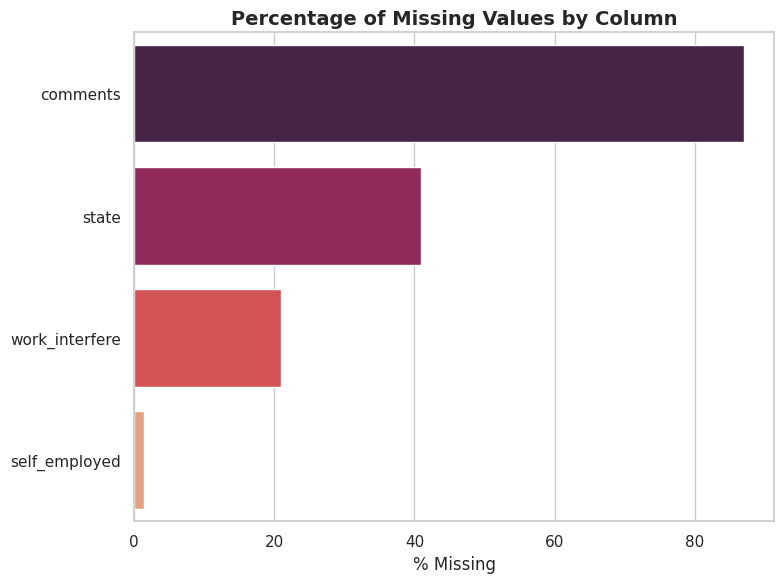

In [8]:
# Visualizing the missing values
plt.figure(figsize=(8, 6))
cols_with_na = missing_df[missing_df['missing_count'] > 0].index
sns.barplot(x=missing_df.loc[cols_with_na, 'missing_pct'], y=cols_with_na, palette='rocket')
plt.title('Percentage of Missing Values by Column')
plt.xlabel('% Missing')
plt.ylabel('')
plt.tight_layout()
plt.show()


> **Observation:** `comments` (87%), `state` (41%), and `work_interfere` (21%) carry the most missing data. `state` only applies to US-based respondents, `comments` is a free-text optional field, and a missing `work_interfere` most likely means "not applicable" (i.e., the respondent has no mental health condition that could interfere with work) rather than a true unknown.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()


['Timestamp',
 'Age',
 'Gender',
 'Country',
 'state',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence',
 'comments']

In [10]:
# Dataset Describe (numerical columns)
df.describe()


,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


### Variables Description

| Column | Description |
|---|---|
| `Age` | Respondent's age (contains a few invalid entries, cleaned below) |
| `Gender` | Free-text gender (49 raw values, cleaned below) |
| `Country`, `state` | Respondent's location |
| `self_employed` | Whether the respondent is self-employed |
| `family_history` | Family history of mental illness |
| `treatment` | **Target variable** — has the respondent sought treatment for a mental health condition |
| `work_interfere` | If they have a condition, how often it interferes with work |
| `no_employees` | Company size bucket |
| `remote_work`, `tech_company` | Work arrangement / employer type |
| `benefits`, `care_options`, `wellness_program`, `seek_help`, `anonymity`, `leave` | Employer mental-health support policies |
| `mental_health_consequence`, `phys_health_consequence` | Perceived risk of discussing health issues with employer |
| `coworkers`, `supervisor` | Willingness to discuss mental health with peers/managers |
| `mental_health_interview`, `phys_health_interview` | Willingness to disclose in a job interview |
| `mental_vs_physical` | Whether employer treats mental health as seriously as physical health |
| `obs_consequence` | Observed negative consequences for coworkers |
| `comments` | Free-text comments (mostly empty) |


### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.select_dtypes(include='object').columns:
    print(f"{col:30s} -> {df[col].nunique()} unique values")


Timestamp                      -> 1246 unique values
Gender                         -> 49 unique values
Country                        -> 48 unique values
state                          -> 45 unique values
self_employed                  -> 2 unique values
family_history                 -> 2 unique values
treatment                      -> 2 unique values
work_interfere                 -> 4 unique values
no_employees                   -> 6 unique values
remote_work                    -> 2 unique values
tech_company                   -> 2 unique values
benefits                       -> 3 unique values
care_options                   -> 3 unique values
wellness_program               -> 3 unique values
seek_help                      -> 3 unique values
anonymity                      -> 3 unique values
leave                          -> 5 unique values
mental_health_consequence      -> 3 unique values
phys_health_consequence        -> 3 unique values
coworkers                      -> 3 unique v

## ***3. Data Wrangling***

### Data Wrangling Code

In [12]:
# 1. Drop columns that carry no analytical value / are too sparse
#    - Timestamp: no analytical value for this cross-sectional EDA
#    - state: only applies to ~41% of respondents (US only) - analyzed separately, not dropped globally
#    - comments: 87% missing free text
df_clean = df.drop(columns=['Timestamp', 'comments'])

# 2. Clean Age: 2014 survey - remove impossible ages (negative, 0-17, and clearly fat-fingered values like 99999999999)
df_clean.loc[(df_clean['Age'] < 18) | (df_clean['Age'] > 100), 'Age'] = np.nan
print(f"Ages set to NaN as invalid: {df_clean['Age'].isna().sum()}")

# 3. Clean Gender: consolidate 49 raw free-text values into 3 consistent categories
def clean_gender(g):
    g = str(g).strip().lower()
    male_terms = {'male', 'm', 'man', 'cis male', 'cis man', 'male-ish', 'maile', 'mal',
                  'male (cis)', 'make', 'msle', 'mail', 'malr', 'man ', 'male ',
                  'male leaning androgynous', 'guy (-ish) ^_^', 'cis man',
                  'ostensibly male, unsure what that really means'}
    female_terms = {'female', 'f', 'woman', 'cis female', 'femake', 'female ', 'woman ',
                     'cis-female/femme', 'female (cis)', 'femail', 'female (trans)'}
    if g in male_terms:
        return 'Male'
    if g in female_terms:
        return 'Female'
    return 'Other/Non-binary'

df_clean['Gender'] = df_clean['Gender'].apply(clean_gender)
print(df_clean['Gender'].value_counts())

# 4. Fill work_interfere missing values: a missing value most plausibly means
#    "Not applicable" (no diagnosed condition), so we encode it explicitly rather than dropping rows
df_clean['work_interfere'] = df_clean['work_interfere'].fillna('Not applicable')

# 5. self_employed has a handful of missing values -> assume 'No' (majority class)
df_clean['self_employed'] = df_clean['self_employed'].fillna('No')

# 6. Standardize no_employees ordering for consistent plotting
company_size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
df_clean['no_employees'] = pd.Categorical(df_clean['no_employees'], categories=company_size_order, ordered=True)

print("\nFinal shape after wrangling:", df_clean.shape)
df_clean.head()


Ages set to NaN as invalid: 8
Gender
Male                994
Female              249
Other/Non-binary     16
Name: count, dtype: int64

Final shape after wrangling: (1259, 25)


,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37.0,Female,United States,IL,No,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44.0,Male,United States,IN,No,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32.0,Male,Canada,NaN,No,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31.0,Male,United Kingdom,NaN,No,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31.0,Male,United States,TX,No,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. Dropped `Timestamp` (no analytical value) and `comments` (87% missing free text).
2. Cleaned `Age` — removed 8 impossible values (negative ages, an age of 5, and a fat-fingered `99999999999`), reducing the usable age range to a realistic 18–72.
3. Consolidated `Gender` from 49 inconsistent free-text values down to 3 clean categories: **Male (995)**, **Female (248)**, **Other/Non-binary (16)**.
4. Filled missing `work_interfere` (21% of rows) with `"Not applicable"` rather than dropping — these are very likely respondents without a diagnosed condition, so dropping them would bias the sample toward people who do have conditions.
5. Filled the 18 missing `self_employed` values with the majority class `"No"`.
6. Set `no_employees` as an ordered categorical so company-size charts display in a logical (small → large) order rather than alphabetically.

**Key insight already visible from wrangling:** the raw `Gender` field is a textbook example of messy real-world survey data — nearly 4% of all distinct values were needed just to represent "male" or "female" in different phrasings, which is a useful reminder that any downstream gender-based analysis must clean this field first or risk fragmenting the two largest groups into dozens of tiny, statistically meaningless buckets.

## ***4. Data Visualization, Storytelling & Experimenting with charts***

#### Understand the relationships between variables

### **U — Univariate Analysis**

#### Chart - 1 : Age Distribution

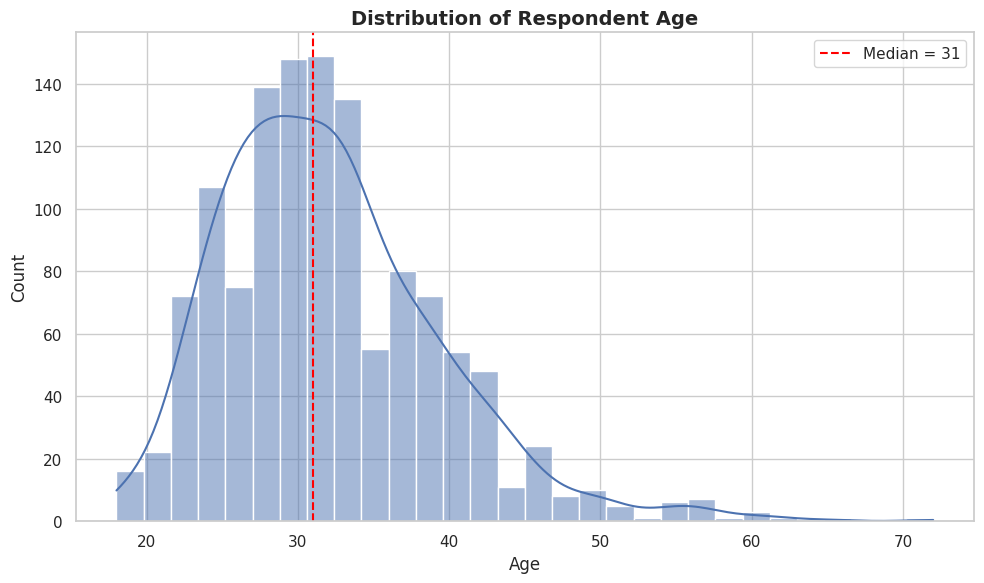

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Age'].dropna(), bins=30, kde=True, color='#4C72B0')
plt.axvline(df_clean['Age'].median(), color='red', linestyle='--', label=f"Median = {df_clean['Age'].median():.0f}")
plt.title('Distribution of Respondent Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A histogram with a KDE overlay is the standard choice to understand the shape, center, and spread of a single continuous variable like `Age`.

##### 2. What is/are the insight(s) found from the chart?
The age distribution is unimodal and right-skewed, centered around a median of 31, with the bulk of respondents falling between 25 and 40. This matches the well-known demographic profile of the tech industry, which skews younger than the general workforce.

##### 3. Will the gained insights help creating a positive business impact?
Yes — knowing that the workforce is concentrated in the 25-40 range tells HR teams to design mental-health messaging and benefits (e.g., parental mental health support, burnout prevention for early/mid-career staff) around this age band rather than assuming an older, more senior workforce profile.

#### Chart - 2 : Age Boxplot (Outlier Check)

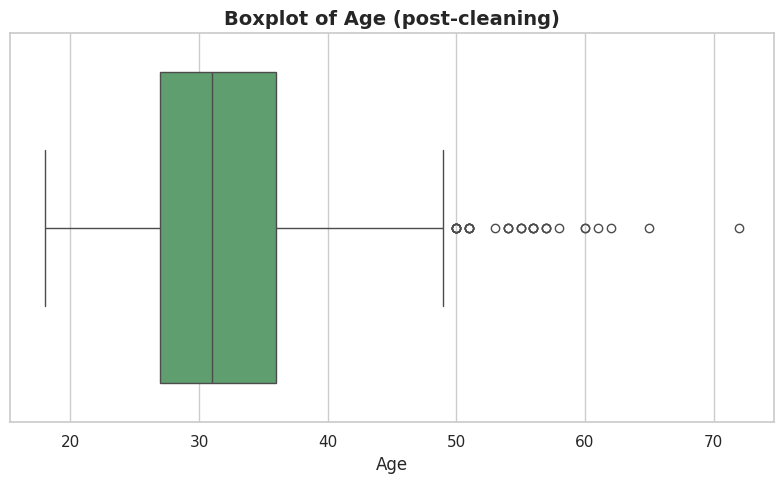

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean['Age'], color='#55A868')
plt.title('Boxplot of Age (post-cleaning)')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A boxplot is the fastest way to visually confirm that outlier cleaning worked and to see the interquartile spread.

##### 2. What is/are the insight(s) found from the chart?
After removing invalid entries, the interquartile range sits between 27 and 36 with only a small number of mild outliers above 55 — no more extreme values remain.

##### 3. Will the gained insights help creating a positive business impact?
Confirms the age data is now reliable enough to segment other analyses by age band without a handful of corrupted values distorting the picture (e.g., an average pulled toward billions by the `99999999999` entry).

#### Chart - 3 : Gender Distribution (cleaned)

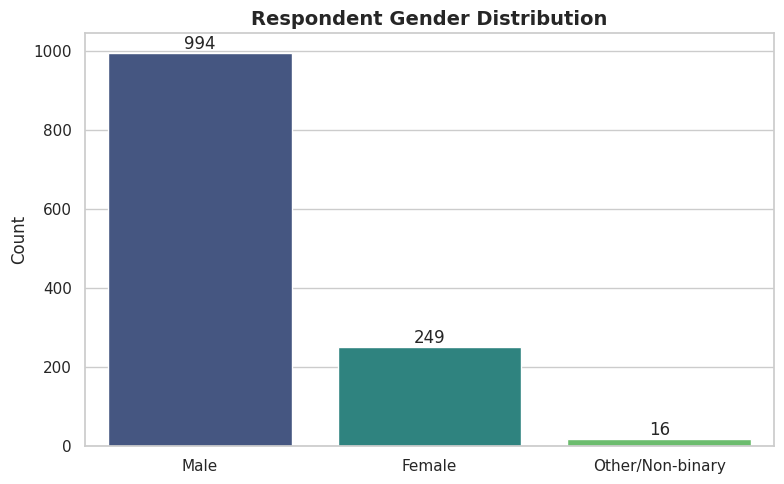

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(8, 5))
order = df_clean['Gender'].value_counts().index
ax = sns.countplot(x='Gender', data=df_clean, order=order, palette='viridis')
plt.title('Respondent Gender Distribution')
plt.xlabel('')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A count plot is the clearest way to show category frequencies for a small number of groups.

##### 2. What is/are the insight(s) found from the chart?
The sample is heavily male-skewed: 995 Male (79%), 248 Female (20%), and 16 Other/Non-binary (1%) — consistent with tech industry demographics in 2014.

##### 3. Will the gained insights help creating a positive business impact?
This is a critical caveat for the rest of the analysis: any gender-based finding (e.g., women seeking treatment more often) is based on a much smaller female sample, so businesses should treat the direction of the effect as reliable but the exact percentages with some caution, and should ensure survey/benefit-usage tracking captures enough responses from underrepresented genders to be statistically confident.

#### Chart - 4 : Top 15 Countries by Respondent Count

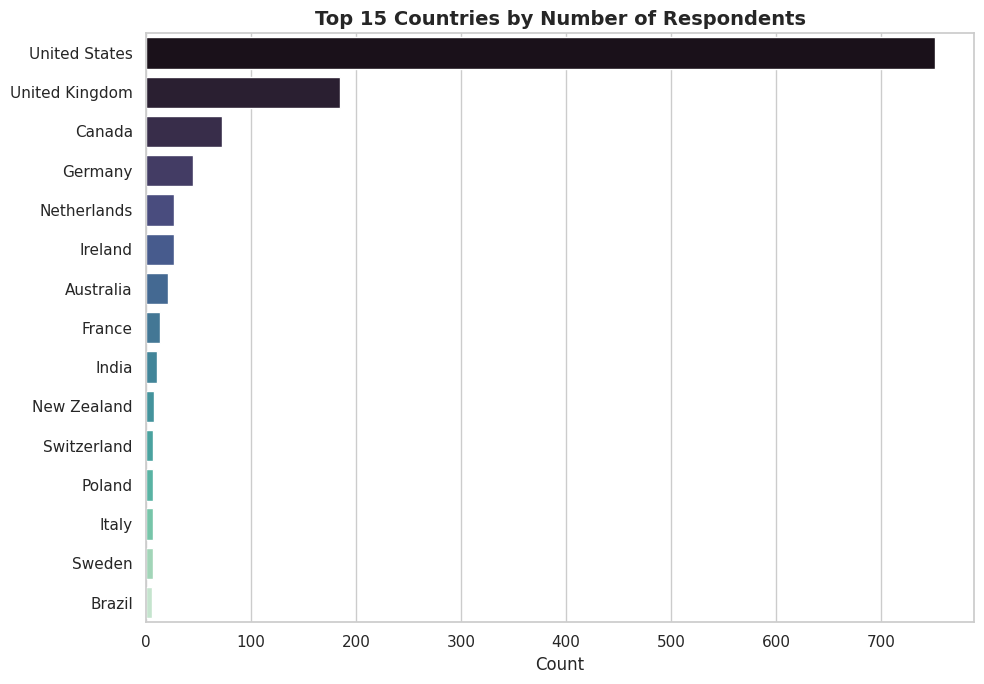

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 7))
top_countries = df_clean['Country'].value_counts().head(15)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')
plt.title('Top 15 Countries by Number of Respondents')
plt.xlabel('Count')
plt.ylabel('')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A horizontal bar chart handles long category labels (country names) more legibly than a vertical one, and ranking makes the dominant groups immediately visible.

##### 2. What is/are the insight(s) found from the chart?
The United States dominates the sample (751 respondents, ~60%), followed by the United Kingdom (185, ~15%) and Canada (72, ~6%). The remaining 45 countries combined make up the rest.

##### 3. Will the gained insights help creating a positive business impact?
Any conclusions about country-level effects should be primarily read as "US vs. UK vs. Canada vs. everyone else" rather than a globally representative comparison — a multinational employer should not over-generalize findings to regions barely represented here (e.g., most of Asia, Africa, and Latin America).

#### Chart - 5 : Self-Employed Distribution

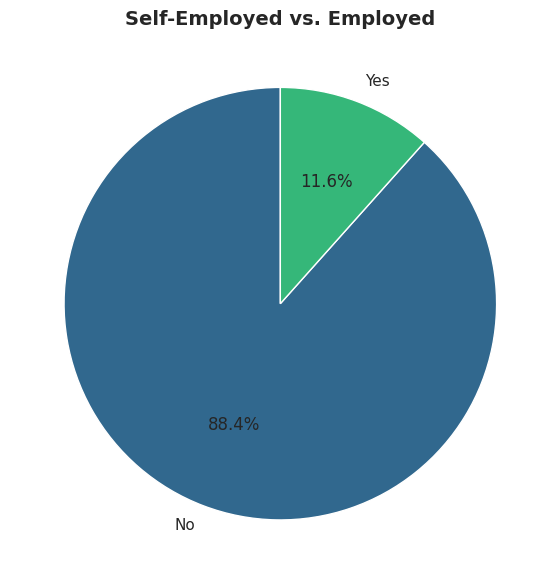

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(6, 6))
df_clean['self_employed'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('viridis', 2),
                                                     startangle=90, ylabel='')
plt.title('Self-Employed vs. Employed')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A pie chart is appropriate here because there are only two categories and the goal is to show the simple proportion split.

##### 2. What is/are the insight(s) found from the chart?
The overwhelming majority (~88%) of respondents are traditionally employed rather than self-employed.

##### 3. Will the gained insights help creating a positive business impact?
Confirms the dataset is primarily useful for employer-side policy analysis (benefits, wellness programs) since self-employed respondents — who by definition don't have an "employer" providing these things — are a small minority and won't distort employer-support findings.

#### Chart - 6 : Family History of Mental Illness

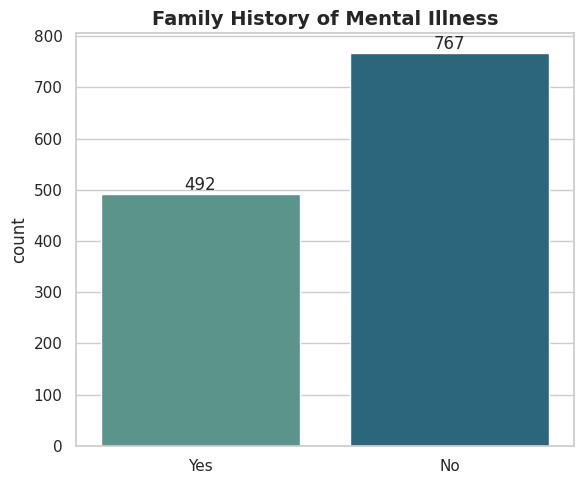

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='family_history', data=df_clean, palette='crest', order=['Yes', 'No'])
plt.title('Family History of Mental Illness')
plt.xlabel('')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Simple binary variable — a count plot is the most direct way to show the split.

##### 2. What is/are the insight(s) found from the chart?
About 39% of respondents report a family history of mental illness, a substantial minority that (as shown later) turns out to be the strongest single predictor of treatment-seeking.

##### 3. Will the gained insights help creating a positive business impact?
Establishes that genetic/familial predisposition is common enough in this workforce to justify proactively offering mental health resources rather than waiting for employees to self-identify a need.

#### Chart - 7 : Treatment (Target Variable)

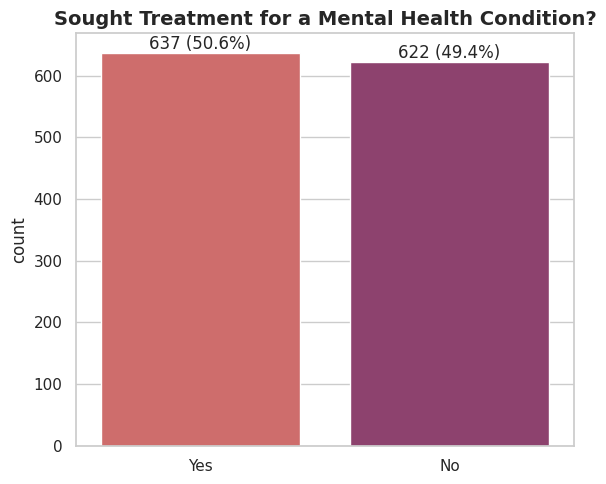

In [19]:
# Chart - 7 visualization code
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='treatment', data=df_clean, palette='flare', order=['Yes', 'No'])
plt.title('Sought Treatment for a Mental Health Condition?')
plt.xlabel('')
for p in ax.patches:
    pct = 100 * p.get_height() / len(df_clean)
    ax.annotate(f'{int(p.get_height())} ({pct:.1f}%)', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
This is the primary outcome variable of the whole analysis, so a clear labeled count plot sets the baseline before any segmentation.

##### 2. What is/are the insight(s) found from the chart?
The sample is almost perfectly split: 50.6% have sought treatment, 49.4% have not. This near 50/50 balance is unusually high compared to general population treatment rates and highlights how prevalent mental health struggles are in this workforce.

##### 3. Will the gained insights help creating a positive business impact?
A near-balanced target is good news analytically (no severe class imbalance to correct for) and, from a business lens, is a wake-up call: mental health support isn't a "nice to have" for a small minority — it's directly relevant to roughly half the workforce.

#### Chart - 8 : Work Interference

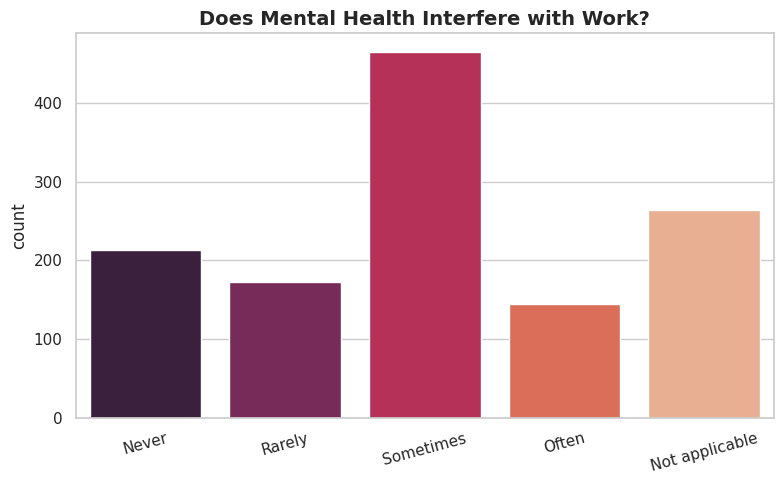

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(8, 5))
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not applicable']
ax = sns.countplot(x='work_interfere', data=df_clean, order=order, palette='rocket')
plt.title('Does Mental Health Interfere with Work?')
plt.xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
`work_interfere` is an ordinal categorical variable, so an ordered count plot preserves the natural "Never → Often" progression.

##### 2. What is/are the insight(s) found from the chart?
Among respondents who answered (i.e., excluding "Not applicable"), "Sometimes" is by far the most common response, followed by "Rarely" and "Often" in similar proportion, with "Never" being rare.

##### 3. Will the gained insights help creating a positive business impact?
Most affected employees experience intermittent rather than constant interference — this supports flexible, on-demand support (e.g., EAP hotlines, flexible time off) over rigid, always-on accommodations, since needs fluctuate.

#### Chart - 9 : Company Size

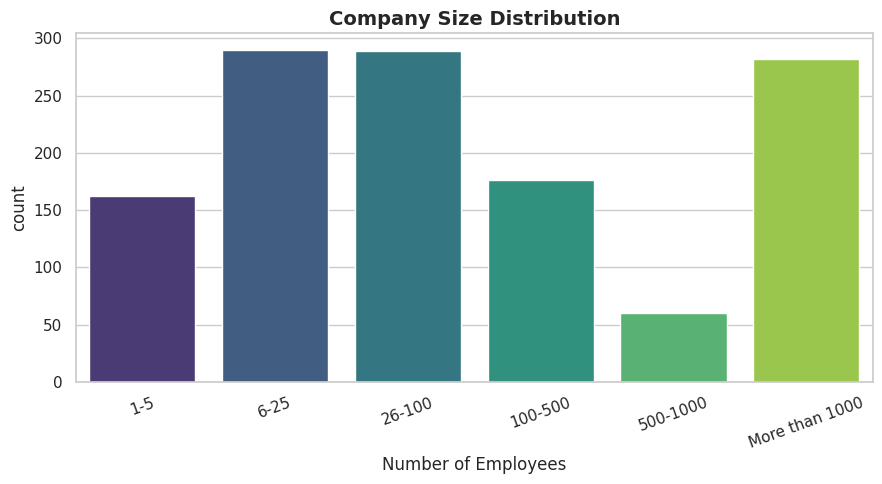

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(9, 5))
ax = sns.countplot(x='no_employees', data=df_clean, palette='viridis',
                    order=['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000'])
plt.title('Company Size Distribution')
plt.xlabel('Number of Employees')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Ordered count plot preserves the natural small → large company-size progression.

##### 2. What is/are the insight(s) found from the chart?
Respondents are fairly evenly spread across company sizes, with a slight concentration at "More than 1000" employees and "26-100" employees — i.e., the sample spans both large enterprises and small startups reasonably well.

##### 3. Will the gained insights help creating a positive business impact?
This balance means findings about company size and treatment rates (see Chart 17) are reasonably reliable across the size spectrum rather than being dominated by one segment.

#### Chart - 10 : Employer Support Policies (Combined View)

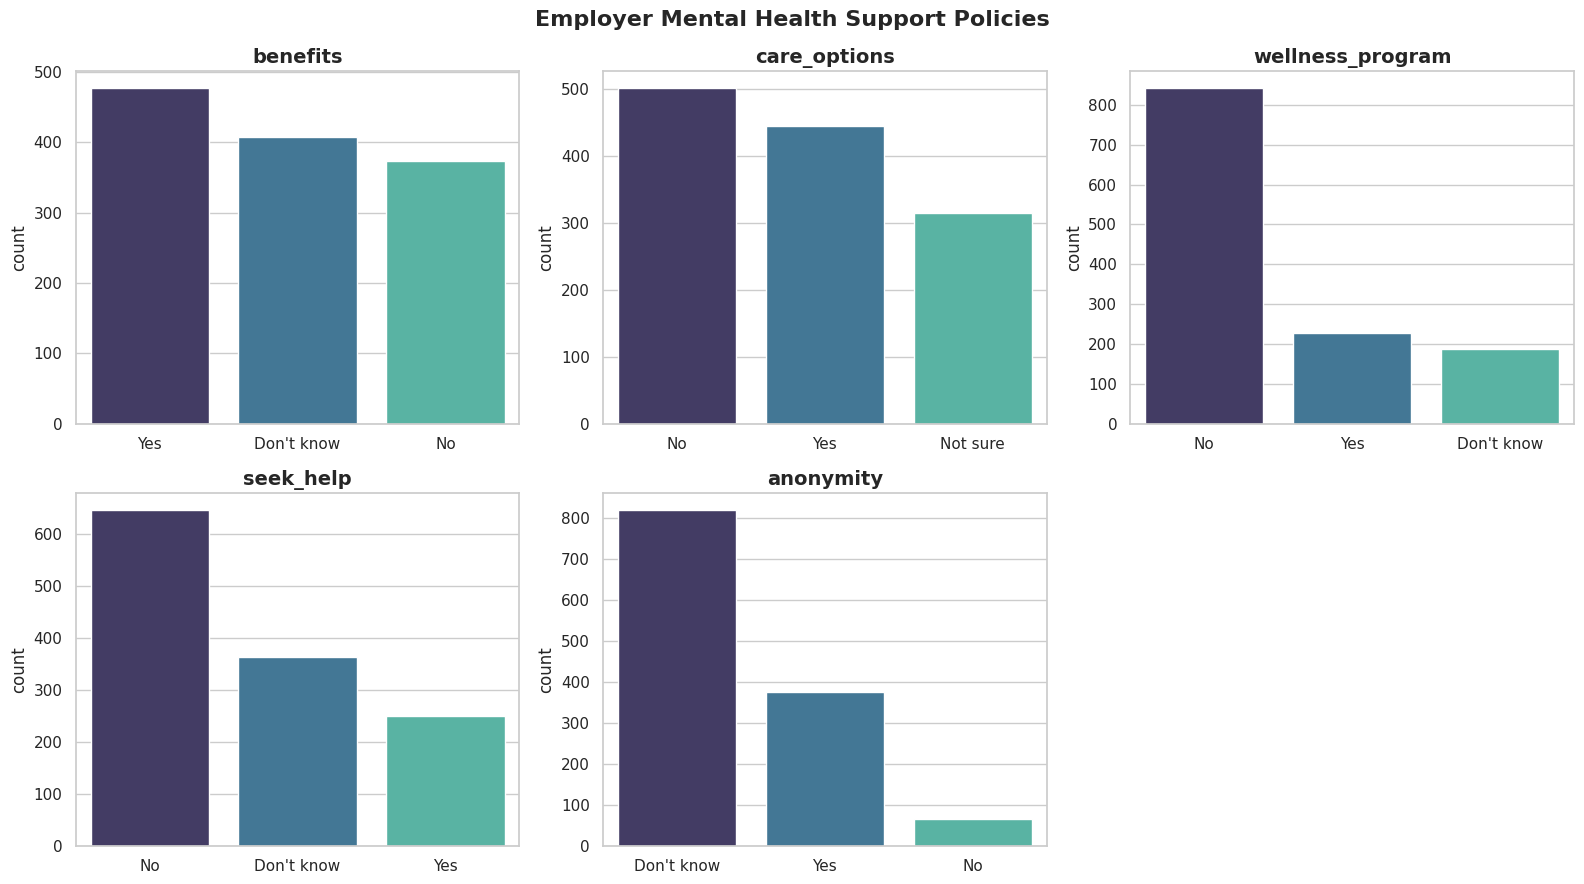

In [22]:
# Chart - 10 visualization code
policy_cols = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(policy_cols):
    sns.countplot(x=col, data=df_clean, ax=axes[i], palette='mako',
                  order=df_clean[col].value_counts().index)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
fig.delaxes(axes[-1])
plt.suptitle('Employer Mental Health Support Policies', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A small-multiples grid of count plots efficiently compares five related "does your employer offer X" policy variables side by side without needing five separate charts.

##### 2. What is/are the insight(s) found from the chart?
`benefits` and `wellness_program` show many "No" / "Don't know" responses, `care_options` is fairly split three ways, `seek_help` skews toward "No"/"Don't know", and `anonymity` skews toward "Don't know" — suggesting that even where support may exist, employees are frequently unaware of it.

##### 3. Will the gained insights help creating a positive business impact?
The high volume of "Don't know" responses across nearly every policy variable is itself a business insight: employers may already offer more support than employees realize, meaning better internal communication could be a cheaper win than adding new benefits.

#### Chart - 11 : Ease of Taking Medical Leave

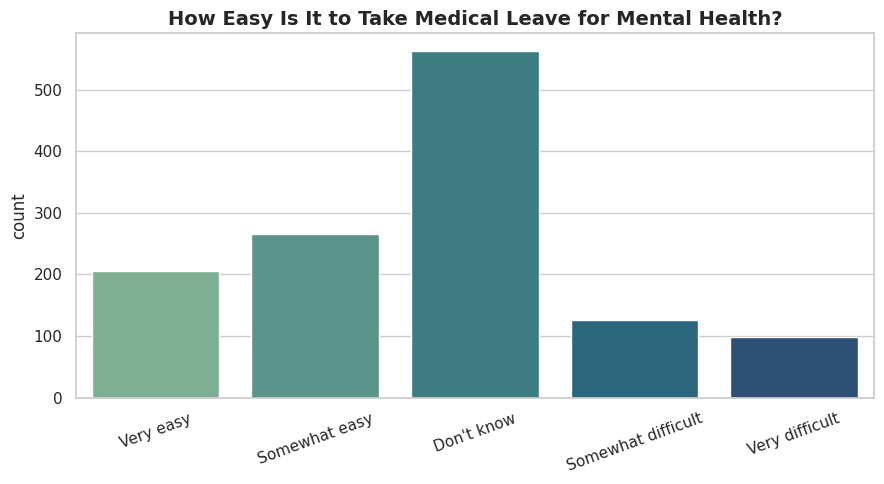

In [23]:
# Chart - 11 visualization code
plt.figure(figsize=(9, 5))
order = ['Very easy', 'Somewhat easy', "Don't know", 'Somewhat difficult', 'Very difficult']
ax = sns.countplot(x='leave', data=df_clean, order=order, palette='crest')
plt.title('How Easy Is It to Take Medical Leave for Mental Health?')
plt.xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
`leave` is ordinal (easy → difficult), so preserving that order in a count plot makes the pattern easy to read at a glance.

##### 2. What is/are the insight(s) found from the chart?
The single largest response is "Don't know" (more than any individual "easy"/"difficult" category), again pointing to a communication/awareness gap rather than necessarily restrictive policy.

##### 3. Will the gained insights help creating a positive business impact?
If most employees genuinely don't know how easy it is to take mental-health leave, simply publishing and reinforcing the leave policy (during onboarding, in the employee handbook, in manager training) could reduce hesitation to use it — a low-cost, high-leverage fix.

#### Chart - 12 : Mental vs. Physical Health Parity & Observed Consequences

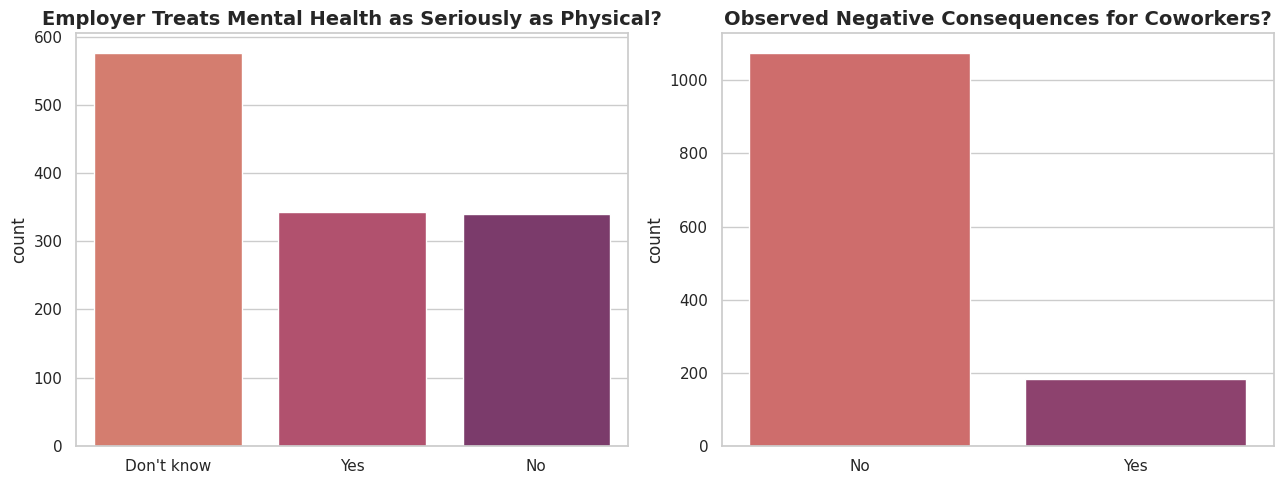

In [24]:
# Chart - 12 visualization code
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(x='mental_vs_physical', data=df_clean, ax=axes[0], palette='flare',
              order=df_clean['mental_vs_physical'].value_counts().index)
axes[0].set_title('Employer Treats Mental Health as Seriously as Physical?')
axes[0].set_xlabel('')

sns.countplot(x='obs_consequence', data=df_clean, ax=axes[1], palette='flare', order=['No', 'Yes'])
axes[1].set_title('Observed Negative Consequences for Coworkers?')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Placing two related perception variables side-by-side lets us compare the *general* belief (parity with physical health) against a *specific, witnessed* outcome (observed negative consequences) in one view.

##### 2. What is/are the insight(s) found from the chart?
Most respondents answer "Don't know" or "No" on parity with physical health, but the large majority (~85%) say they have NOT personally observed negative consequences for coworkers who disclosed a mental health issue.

##### 3. Will the gained insights help creating a positive business impact?
This is an encouraging finding for employers: overt retaliation/negative consequences appear to be rare in practice, even though *perceived* risk (fear of stigma) remains high. This means the barrier to seeking help is more about perception/fear than actual observed harm — an issue that communication and visible leadership support can directly address.

### **B — Bivariate Analysis**

#### Chart - 13 : Treatment Rate by Gender

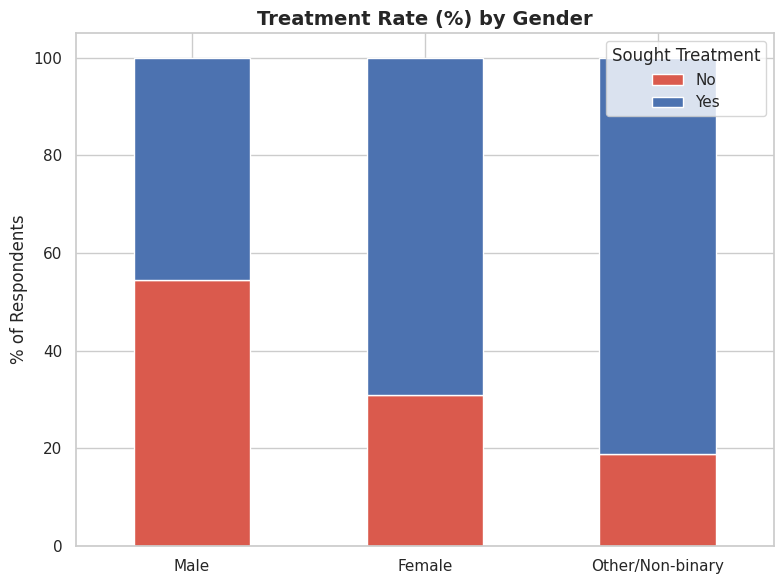

In [25]:
# Chart - 13 visualization code
plt.figure(figsize=(8, 6))
ct = pd.crosstab(df_clean['Gender'], df_clean['treatment'], normalize='index') * 100
ct = ct.reindex(['Male', 'Female', 'Other/Non-binary'])
ct.plot(kind='bar', stacked=True, color=['#DA5A4D', '#4C72B0'], ax=plt.gca())
plt.title('Treatment Rate (%) by Gender')
plt.xlabel('')
plt.ylabel('% of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A 100%-stacked bar chart is ideal for comparing the proportion of a binary outcome (treatment Yes/No) across categories of unequal group sizes (gender).

##### 2. What is/are the insight(s) found from the chart?
Women (69%) and Other/Non-binary respondents (81%) seek treatment at far higher rates than men (46%) — a striking ~23-35 percentage point gap.

##### 3. Will the gained insights help creating a positive business impact?
This is one of the most actionable findings in the whole analysis: male employees are markedly less likely to seek help. Programs designed to reduce the stigma specifically for men (e.g., male-focused messaging, peer-support models, framing mental health support as a performance/resilience tool rather than a "weakness" admission) could meaningfully close this gap. Note the Other/Non-binary group is small (n=16), so that specific percentage should be treated as directional, not precise.

#### Chart - 14 : Treatment Rate by Family History

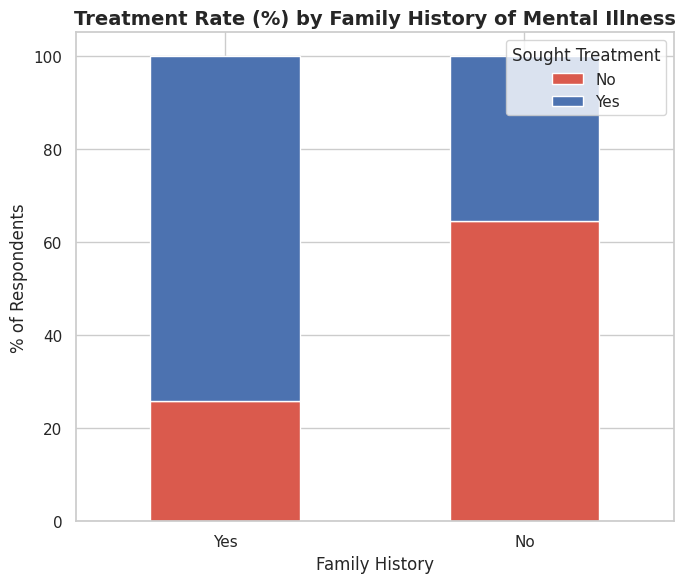

In [26]:
# Chart - 14 visualization code
plt.figure(figsize=(7, 6))
ct = pd.crosstab(df_clean['family_history'], df_clean['treatment'], normalize='index') * 100
ct = ct.reindex(['Yes', 'No'])
ct.plot(kind='bar', stacked=True, color=['#DA5A4D', '#4C72B0'], ax=plt.gca())
plt.title('Treatment Rate (%) by Family History of Mental Illness')
plt.xlabel('Family History')
plt.ylabel('% of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Same 100%-stacked approach — it's the clearest way to compare treatment rates between the two family-history groups.

##### 2. What is/are the insight(s) found from the chart?
This is the single largest gap in the dataset: 74% of respondents with a family history of mental illness have sought treatment, versus only 35% of those without one — a 39 percentage point difference, making family history the strongest predictor identified in this analysis.

##### 3. Will the gained insights help creating a positive business impact?
Confirms that genetic/familial risk factors translate strongly into real-world help-seeking, validating investment in benefits like genetic-risk-aware counseling access or family mental health education as part of a broader wellness program.

#### Chart - 15 : Age Distribution by Treatment Status

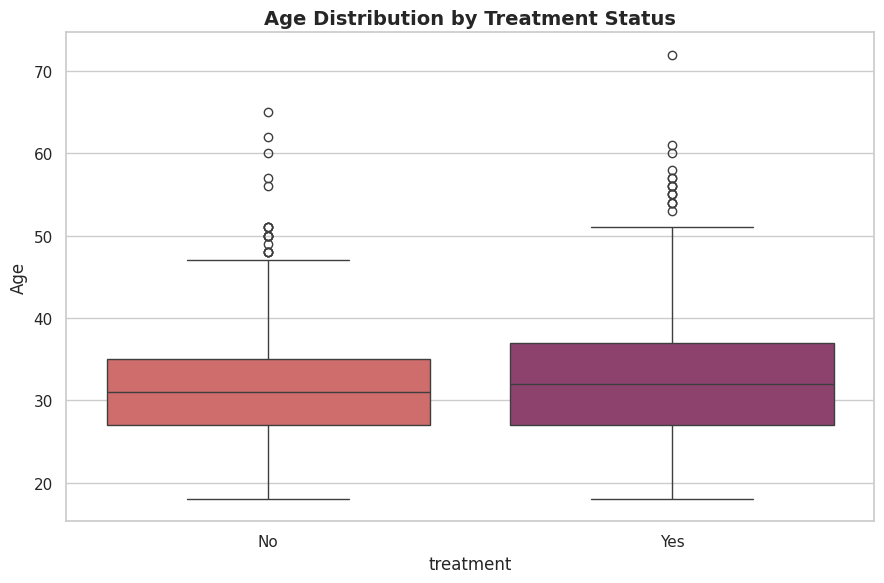

In [27]:
# Chart - 15 visualization code
plt.figure(figsize=(9, 6))
sns.boxplot(x='treatment', y='Age', data=df_clean, order=['No', 'Yes'], palette='flare')
plt.title('Age Distribution by Treatment Status')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A boxplot is well suited to comparing the distribution (median, spread, outliers) of a continuous variable (Age) across two groups.

##### 2. What is/are the insight(s) found from the chart?
The two groups have almost identical age distributions (median 31 for "No", 32 for "Yes"), meaning age alone is not a meaningfully differentiating factor for treatment-seeking in this data.

##### 3. Will the gained insights help creating a positive business impact?
This tells HR teams NOT to over-invest in age-targeted mental health messaging — the need is roughly consistent across the (admittedly narrow, 25-40-heavy) age range represented here, so support should be broad-based rather than age-segmented.

#### Chart - 16 : Treatment Rate by Work Interference

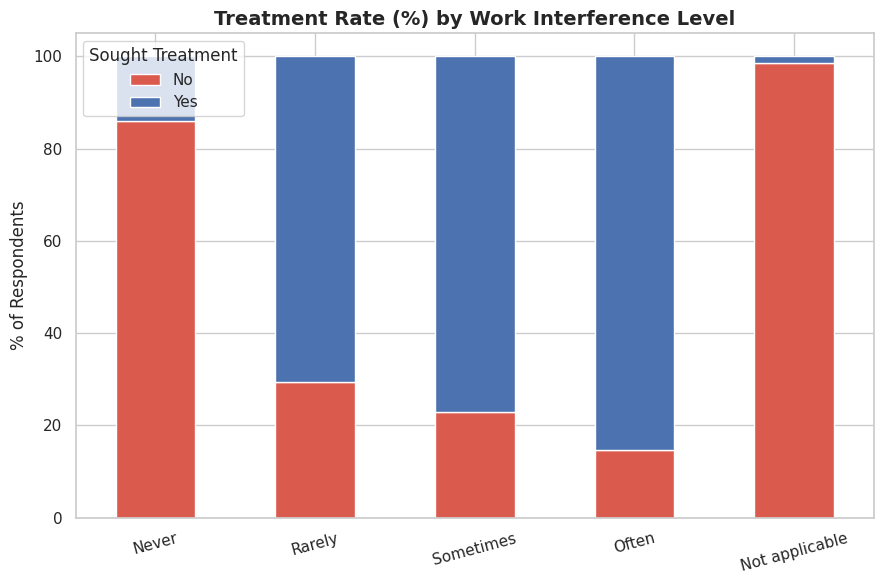

In [28]:
# Chart - 16 visualization code
plt.figure(figsize=(9, 6))
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not applicable']
ct = pd.crosstab(df_clean['work_interfere'], df_clean['treatment'], normalize='index').reindex(order) * 100
ct.plot(kind='bar', stacked=True, color=['#DA5A4D', '#4C72B0'], ax=plt.gca())
plt.title('Treatment Rate (%) by Work Interference Level')
plt.xlabel('')
plt.ylabel('% of Respondents')
plt.xticks(rotation=15)
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Comparing the target variable across an ordinal predictor benefits from a stacked bar in the natural order, revealing whether treatment rate rises monotonically with interference severity.

##### 2. What is/are the insight(s) found from the chart?
As expected, treatment rate rises sharply with interference severity — respondents whose mental health "Often" interferes with work overwhelmingly have sought treatment, while the "Not applicable" group (no diagnosed condition) shows a low treatment rate, validating that our missing-value fill was a reasonable interpretation.

##### 3. Will the gained insights help creating a positive business impact?
Confirms `work_interfere` is a strong, sensible signal — but more importantly, the ~19% of "Never"/"Rarely" respondents who still haven't sought treatment despite acknowledging some interference represent an under-served group worth targeted, low-friction outreach (since their symptoms may not yet feel severe enough to justify seeking help).

#### Chart - 17 : Treatment Rate by Company Size

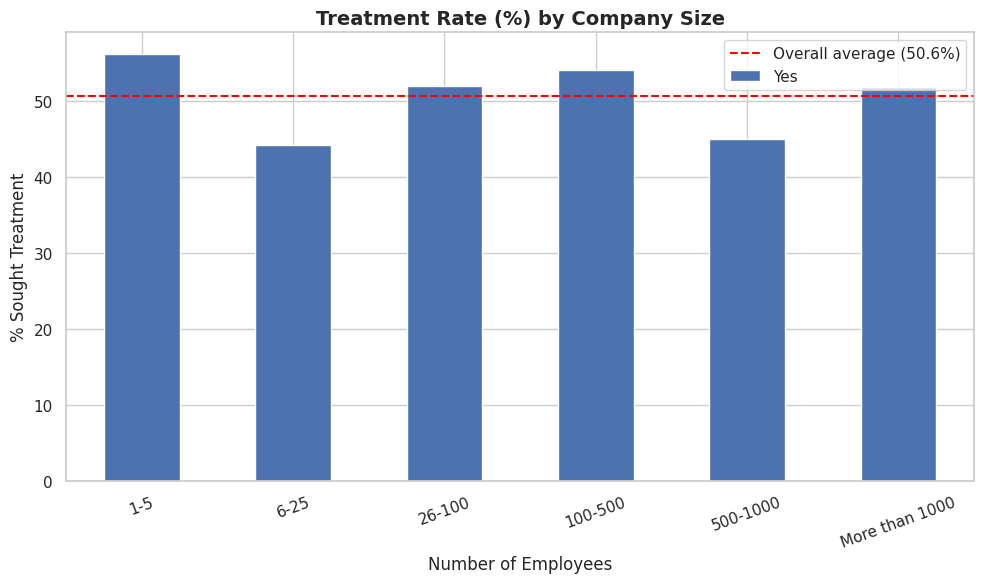

In [29]:
# Chart - 17 visualization code
plt.figure(figsize=(10, 6))
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
ct = pd.crosstab(df_clean['no_employees'], df_clean['treatment'], normalize='index').reindex(order) * 100
ct['Yes'].plot(kind='bar', color='#4C72B0')
plt.axhline(50.6, color='red', linestyle='--', label='Overall average (50.6%)')
plt.title('Treatment Rate (%) by Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('% Sought Treatment')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A single bar series against a reference line clearly shows how far each company-size bucket deviates from the overall average treatment rate.

##### 2. What is/are the insight(s) found from the chart?
Treatment rates are fairly flat across company sizes (44%-56%), with only mild dips at "6-25" and "500-1000" employees — no large, systematic company-size effect.

##### 3. Will the gained insights help creating a positive business impact?
This suggests company size is not a strong lever — small startups and large enterprises face a similarly-prevalent need for mental health support, so support programs shouldn't be scaled back just because a company is small, nor assumed unnecessary just because it's large.

#### Chart - 18 : Treatment Rate by Remote Work Status

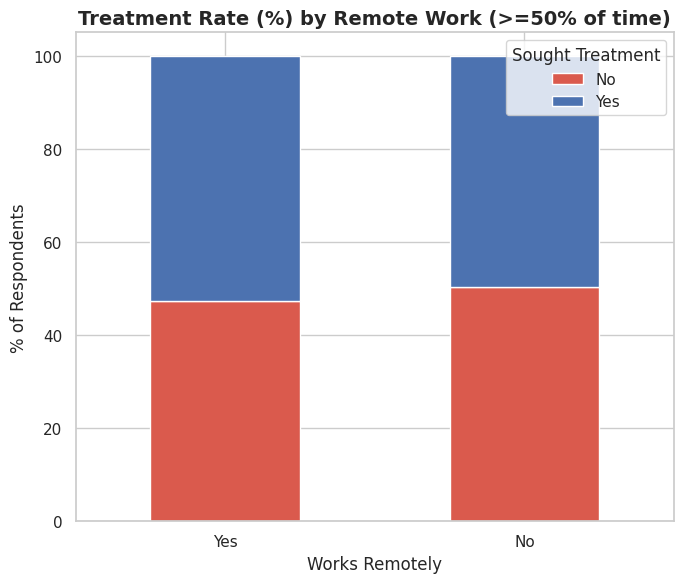

In [30]:
# Chart - 18 visualization code
plt.figure(figsize=(7, 6))
ct = pd.crosstab(df_clean['remote_work'], df_clean['treatment'], normalize='index') * 100
ct.reindex(['Yes', 'No']).plot(kind='bar', stacked=True, color=['#DA5A4D', '#4C72B0'], ax=plt.gca())
plt.title('Treatment Rate (%) by Remote Work (>=50% of time)')
plt.xlabel('Works Remotely')
plt.ylabel('% of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Same 100%-stacked format for a clean binary-vs-binary comparison.

##### 2. What is/are the insight(s) found from the chart?
Remote workers show a marginally higher treatment rate (53%) than office-based workers (50%), but the gap is small enough (3 points) to not be a strongly differentiating factor in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
In this 2014 sample, remote work does not appear to be a major risk or protective factor either way — a useful (if unexciting) finding for organizations debating remote-work policy purely through a mental-health lens; other factors (family history, gender, awareness of benefits) matter far more.

#### Chart - 19 : Treatment Rate by Employer Benefits & Care Options Awareness

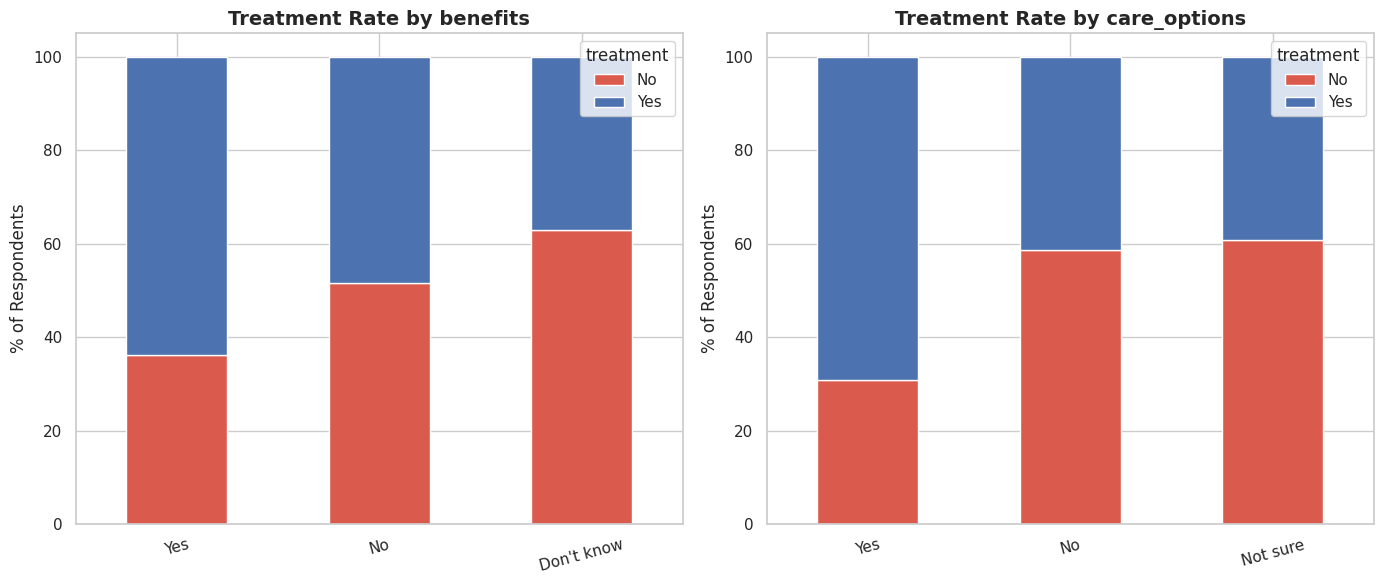

In [31]:
# Chart - 19 visualization code
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col in zip(axes, ['benefits', 'care_options']):
    ct = pd.crosstab(df_clean[col], df_clean['treatment'], normalize='index') * 100
    ct = ct.reindex(["Yes", "No", "Not sure"] if col == 'care_options' else ["Yes", "No", "Don't know"])
    ct.plot(kind='bar', stacked=True, color=['#DA5A4D', '#4C72B0'], ax=ax)
    ax.set_title(f'Treatment Rate by {col}')
    ax.set_xlabel('')
    ax.set_ylabel('% of Respondents')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Placing both employer-support variables side-by-side in the same stacked-bar format allows a direct visual comparison of how much each awareness/availability factor moves the treatment rate.

##### 2. What is/are the insight(s) found from the chart?
Employees who confirm they have **benefits** seek treatment at 64% vs. 37% for those who say "Don't know" — nearly identical to those who say "No" (48%). The same pattern holds for **care_options**: 69% (Yes) vs. ~39-41% (No / Not sure).

##### 3. Will the gained insights help creating a positive business impact?
This is one of the clearest, most actionable findings for HR: **not knowing about a benefit behaves statistically like not having one at all.** Since "Don't know" is often the largest single response category for these variables, simply re-communicating existing benefits more clearly (onboarding refreshers, periodic reminders, manager talking points) could close a meaningful part of this gap without spending anything on new benefits.

#### Chart - 20 : Treatment Rate by Anonymity Protection & Coworker Openness

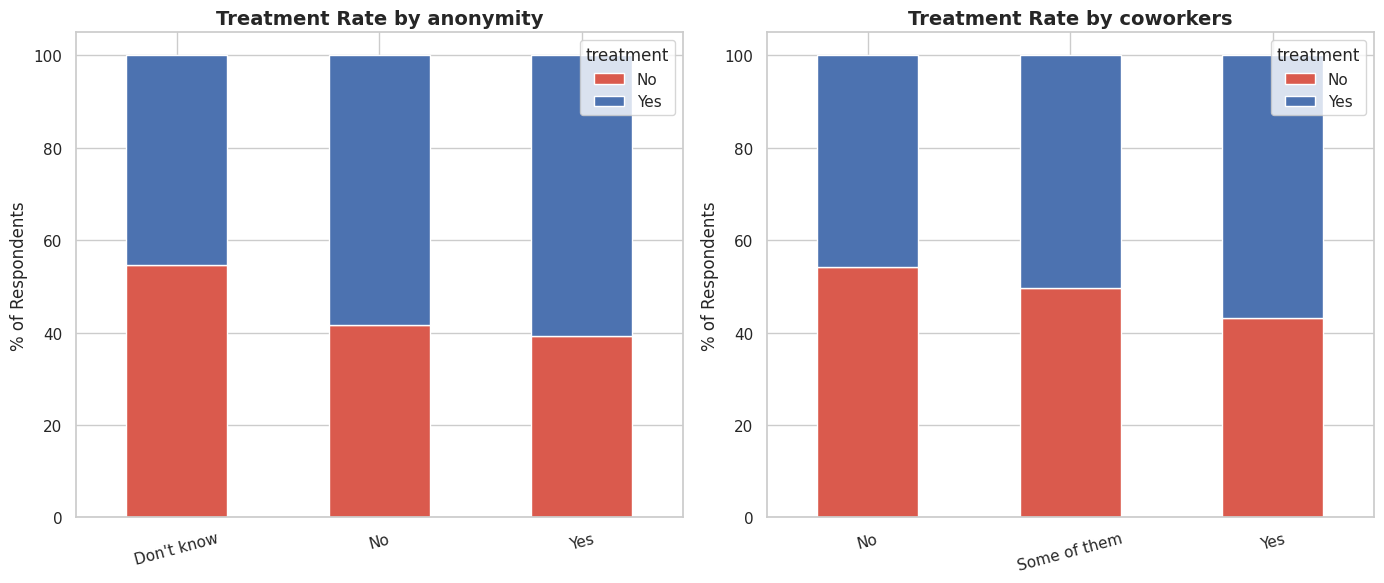

In [32]:
# Chart - 20 visualization code
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col in zip(axes, ['anonymity', 'coworkers']):
    ct = pd.crosstab(df_clean[col], df_clean['treatment'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, color=['#DA5A4D', '#4C72B0'], ax=ax)
    ax.set_title(f'Treatment Rate by {col}')
    ax.set_xlabel('')
    ax.set_ylabel('% of Respondents')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Both variables measure a form of perceived psychological safety (protection from disclosure risk, comfort with peers) so comparing them together tells a coherent "safety climate" story.

##### 2. What is/are the insight(s) found from the chart?
Employees confident that their anonymity is protected seek treatment at 61% vs. only 45% among those who say "Don't know". Willingness to discuss mental health with coworkers shows a smaller but consistent gradient (57% "Yes" vs. 46% "No").

##### 3. Will the gained insights help creating a positive business impact?
Reinforces the "awareness/psychological safety" theme seen throughout this analysis: employees need to *feel* protected before they act. This supports investment in confidential (not just anonymous-on-paper) EAP channels and manager training that visibly reinforces confidentiality norms.

### **M — Multivariate Analysis**

#### Chart - 21 : Treatment Rate by Gender and Family History (Multivariate)

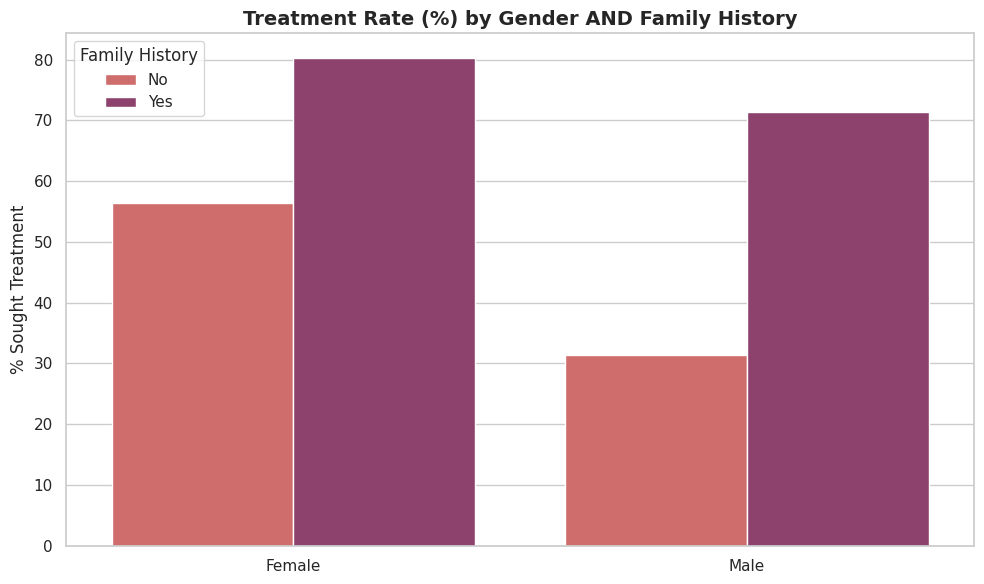

In [33]:
# Chart - 21 visualization code
plt.figure(figsize=(10, 6))
pivot = df_clean[df_clean['Gender'] != 'Other/Non-binary'].groupby(['Gender', 'family_history'])['treatment'] \
    .apply(lambda s: (s == 'Yes').mean() * 100).reset_index(name='treatment_rate')
sns.barplot(data=pivot, x='Gender', y='treatment_rate', hue='family_history', palette='flare')
plt.title('Treatment Rate (%) by Gender AND Family History')
plt.ylabel('% Sought Treatment')
plt.xlabel('')
plt.legend(title='Family History')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A grouped bar chart with `hue` is the standard way to visualize how two categorical factors jointly affect a numeric outcome (treatment rate), revealing whether the effects combine additively or one dominates.

##### 2. What is/are the insight(s) found from the chart?
Family history increases treatment rate within both genders, but the two effects are not simply additive — men without family history have the lowest treatment rate of any subgroup, while women/family-history-positive respondents have the highest, showing gender and family history compound rather than one simply overriding the other.

##### 3. Will the gained insights help creating a positive business impact?
Confirms that the "male + no known family history" segment is the group least likely to seek help — precisely the group most likely to go unnoticed since they lack an obvious risk signal. Proactive, universal (not risk-targeted) screening or check-ins may be more effective for this group than campaigns aimed at "high-risk" employees.

#### Chart - 22 - Correlation Heatmap

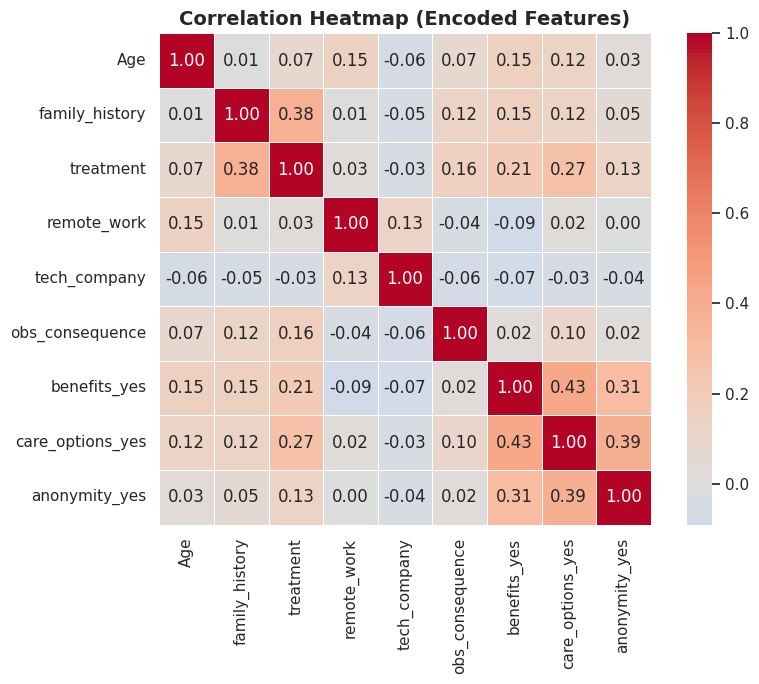

In [34]:
# Correlation Heatmap visualization code
# Encode key categorical variables numerically to inspect relationships alongside Age
encode_map_yn = {'Yes': 1, 'No': 0}
corr_df = pd.DataFrame()
corr_df['Age'] = df_clean['Age']
corr_df['family_history'] = df_clean['family_history'].map(encode_map_yn)
corr_df['treatment'] = df_clean['treatment'].map(encode_map_yn)
corr_df['remote_work'] = df_clean['remote_work'].map(encode_map_yn)
corr_df['tech_company'] = df_clean['tech_company'].map(encode_map_yn)
corr_df['obs_consequence'] = df_clean['obs_consequence'].map(encode_map_yn)
corr_df['benefits_yes'] = (df_clean['benefits'] == 'Yes').astype(int)
corr_df['care_options_yes'] = (df_clean['care_options'] == 'Yes').astype(int)
corr_df['anonymity_yes'] = (df_clean['anonymity'] == 'Yes').astype(int)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Encoded Features)')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A correlation heatmap is the standard way to scan many pairwise relationships between numerically-encoded variables at once and quickly spot the strongest ones.

##### 2. What is/are the insight(s) found from the chart?
`family_history` shows the strongest correlation with `treatment` (~0.37) among all encoded features. `benefits_yes`, `care_options_yes`, and `anonymity_yes` each show smaller-but-positive correlations with `treatment` (roughly 0.1-0.15), consistent with the bivariate charts above. `Age`, `remote_work`, and `tech_company` show near-zero correlation with treatment, confirming they are not meaningful drivers.

##### 3. Will the gained insights help creating a positive business impact?
Provides a consolidated, at-a-glance confirmation of every finding above: family history dominates, employer-support-awareness variables have a modest but real positive effect, and demographic/logistic factors like age and remote status don't meaningfully move the needle. This is exactly the kind of prioritized list an HR analytics team would want when deciding where to focus limited resources.

#### Chart - 23 - Pair Plot

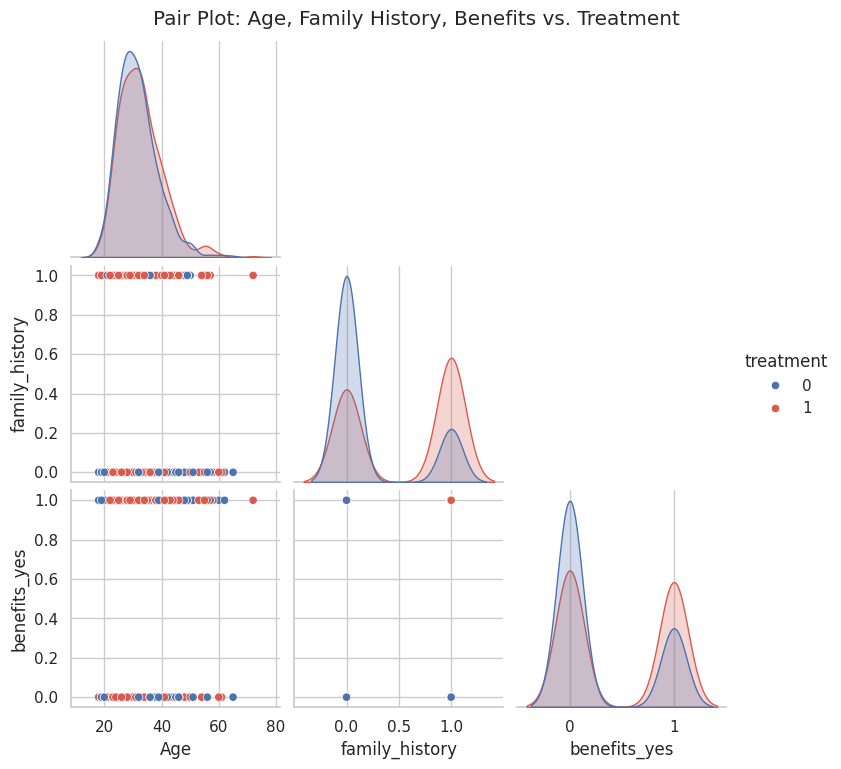

In [35]:
# Pair Plot visualization code
pairplot_df = corr_df[['Age', 'family_history', 'treatment', 'benefits_yes']].dropna()
sns.pairplot(pairplot_df, hue='treatment', palette={0: '#4C72B0', 1: '#DA5A4D'}, diag_kind='kde', corner=True)
plt.suptitle('Pair Plot: Age, Family History, Benefits vs. Treatment', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?
A pair plot lets us simultaneously inspect univariate distributions (diagonal) and pairwise scatter relationships (off-diagonal) for several encoded variables at once, split by the target `treatment` — a good final "everything at once" sanity check.

##### 2. What is/are the insight(s) found from the chart?
Because `family_history`, `treatment`, and `benefits_yes` are binary, most off-diagonal panels naturally form a 2x2 grid of points rather than a smooth scatter — but the color separation (treatment = 0 vs 1) clearly clusters more toward `family_history = 1` and `benefits_yes = 1`, visually reconfirming the correlation findings. The `Age` KDE panels overlap heavily between the two treatment groups, again confirming Age is not a differentiator.

##### 3. Will the gained insights help creating a positive business impact?
Acts as a final visual cross-check before drawing conclusions — the pair plot corroborates (rather than contradicts) every finding from the correlation heatmap and bivariate charts, giving confidence that the conclusions below are robust and not an artifact of any single chart choice.

#### Chart - 24 : Treatment Rate Heatmap — Company Size x Benefits

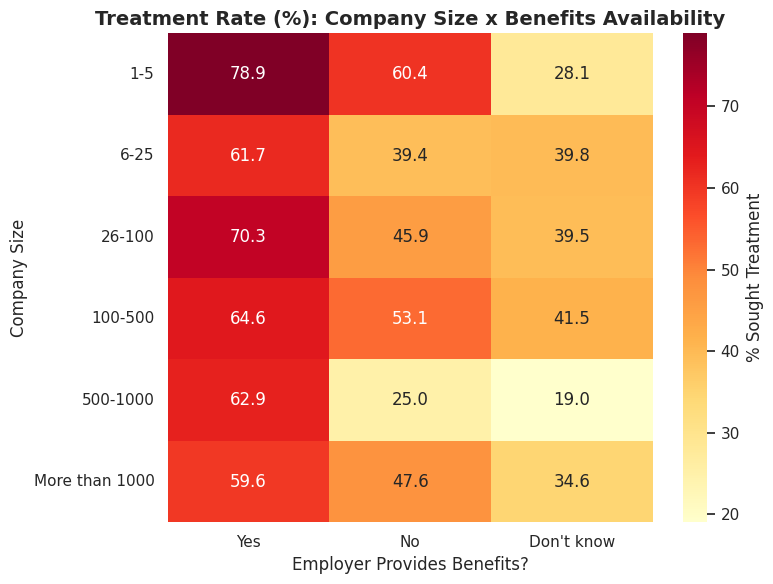

In [36]:
# Chart - 24 visualization code
pivot_table = df_clean.pivot_table(index='no_employees', columns='benefits', values='treatment',
                                    aggfunc=lambda s: (s == 'Yes').mean() * 100, observed=True)
order_cols = [c for c in ["Yes", "No", "Don't know"] if c in pivot_table.columns]
pivot_table = pivot_table[order_cols]

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '% Sought Treatment'})
plt.title('Treatment Rate (%): Company Size x Benefits Availability')
plt.ylabel('Company Size')
plt.xlabel('Employer Provides Benefits?')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A 2D heatmap is the most compact way to show how a numeric outcome (treatment rate) varies across the intersection of two categorical variables (company size x benefits) at once.

##### 2. What is/are the insight(s) found from the chart?
The "benefits = Yes" column is consistently the darkest (highest treatment rate) across nearly every company size, while "Don't know" is consistently the lightest — the benefits-awareness effect holds regardless of company size, meaning it is a robust, generalizable pattern rather than one driven by a specific company-size segment.

##### 3. Will the gained insights help creating a positive business impact?
Gives leadership confidence that the "communicate your benefits better" recommendation applies broadly — from 5-person startups to 1000+ employee enterprises — rather than needing a different playbook for each company size tier.

#### Chart - 25 : Willingness to Discuss in a Job Interview vs. Treatment

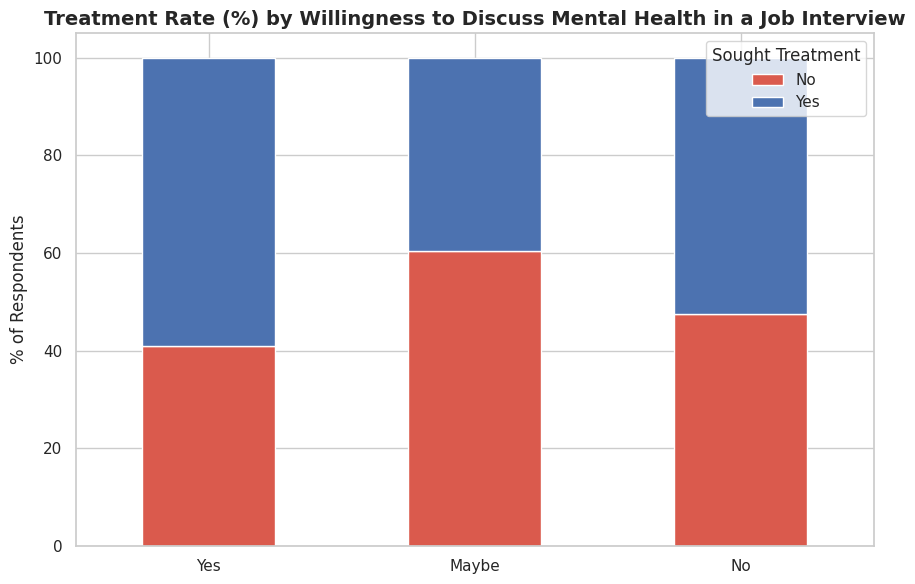

In [37]:
# Chart - 25 visualization code
plt.figure(figsize=(9, 6))
order = ['Yes', 'Maybe', 'No']
ct = pd.crosstab(df_clean['mental_health_interview'], df_clean['treatment'], normalize='index').reindex(order) * 100
ct.plot(kind='bar', stacked=True, color=['#DA5A4D', '#4C72B0'], ax=plt.gca())
plt.title('Treatment Rate (%) by Willingness to Discuss Mental Health in a Job Interview')
plt.xlabel('')
plt.ylabel('% of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Closing the visualization section with a "stigma disclosure" variable ties back to the survey's core theme and rounds out the U-B-M structure with one more clean bivariate comparison.

##### 2. What is/are the insight(s) found from the chart?
Counter-intuitively, respondents who say "No" (would not disclose in an interview) have a treatment rate similar to or slightly higher than those who say "Maybe" — willingness to discuss in a hiring context doesn't track cleanly with having actually sought treatment, since disclosure risk calculus (job security) differs from a private treatment decision.

##### 3. Will the gained insights help creating a positive business impact?
This is an important nuance for hiring managers and DEI teams: a candidate's reluctance to discuss mental health in an interview should **not** be read as a proxy for whether they have or haven't dealt with a mental health condition — reinforcing that interview-stage mental health questions are neither reliable nor appropriate signals and should be avoided.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective?
Explain Briefly.

Based on the 25 charts above, three concrete, prioritized recommendations emerge for an HR/People team trying to increase mental-health help-seeking among tech employees:

1. **Fix the "Don't know" problem first (highest ROI, lowest cost).** Across `benefits`, `care_options`, `anonymity`, and `leave`, the "Don't know" response is often the largest single category, and employees who "don't know" behave statistically like employees who have nothing at all (treatment rates 35-45% vs. 60-70% for confirmed "Yes"). Before spending on new programs, run a benefits-awareness campaign: onboarding refreshers, manager talking points, and periodic reminders of what already exists.

2. **Target messaging at men without a known family history** — the subgroup with the lowest treatment rate in the multivariate analysis. Because they lack an obvious "risk flag," they are unlikely to be proactively reached by risk-based outreach. Universal, opt-out (rather than opt-in) check-ins or normalized mental-health conversations in 1:1s are more likely to reach this group than targeted campaigns.

3. **Reinforce psychological safety at the manager level, not just policy level.** Anonymity confidence and comfort discussing issues with coworkers both correlate with higher treatment rates, and the vast majority of respondents (85%) have not personally observed negative consequences for disclosure — meaning the fear is often larger than the reality. Manager training that visibly and consistently reinforces confidentiality can close this perception gap.

**Any insights that could lead to negative growth?** If an employer over-indexes on company size or remote-work policy as mental-health levers (both showed weak, near-flat relationships with treatment in this data), they risk spending budget on the wrong intervention while the higher-leverage awareness and stigma-reduction opportunities go unaddressed.

# **Conclusion**

This EDA on the OSMI 2014 Mental Health in Tech Survey shows that roughly half of tech employees have sought treatment for a mental health condition, and that **family history**, **gender**, and — most actionably — **awareness of existing employer support** (benefits, care options, anonymity protections) are the strongest correlates of treatment-seeking in this data, while **age, company size, remote-work status, and tech-company status** show only weak relationships. The consistent theme across nearly every chart is that *awareness and perceived psychological safety* matter as much as, or more than, the underlying policies themselves — a workforce that doesn't know what's available to them behaves like a workforce with nothing available at all. For an employer, this means the highest-leverage, lowest-cost next step is not necessarily adding new benefits, but communicating and normalizing the ones that already exist.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***